# **Notebook 4: Lung Segmentation Preprocessing Test**

**Description:** This notebook tests whether lung-focused image preprocessing improves the Bio_ClinicalBERT residual gated fusion classifier carried forward from Notebook 03. It keeps the saved splits, text branch, image encoder, residual gated fusion architecture, training budget, and reporting outputs aligned, then changes only the image inputs by comparing original full images with segmentation-derived variants.

**Main Questions This Notebook Should Answer:**
- Do lung cropping or lung masking improve generalization?
- Does segmentation help balanced minority-class performance, or only raw accuracy?
- Should the final model use the original full-image pipeline before moving into tuning and Grad-CAM interpretation?

---

# **Part 1: Configuration**
### **Imports and Configuration**


In [1]:
from pathlib import Path
import sys
import gc
import json
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

from transformers import (
    AutoImageProcessor,
    AutoModel,
    AutoModelForSemanticSegmentation,
    AutoTokenizer,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

project_root = Path.cwd().resolve()
if not (project_root / "splits").exists():
    project_root = project_root.parent

base_dir = project_root
split_dir = base_dir / "splits"

train_csv = split_dir / "train.csv"
val_csv = split_dir / "val.csv"
test_csv = split_dir / "test.csv"

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

HF_CACHE_DIR = base_dir / "hf_cache"
IMG_SIZE = 224
SEG_IMG_SIZE = 512
BATCH_SIZE = 32
NUM_WORKERS = 0
EPOCHS = 10
LR_TEXT = 2e-5
LR_IMAGE = 1e-4
WEIGHT_DECAY = 1e-4
MAX_LEN = 64
FREEZE_BERT = True
FREEZE_IMAGE_BACKBONE = False

TEXT_ENCODER_NAME = "emilyalsentzer/Bio_ClinicalBERT"
TOKENIZER_NAME = TEXT_ENCODER_NAME
TEXT_ENCODER_SPEC = {
    "name": "Bio_ClinicalBERT",
    "slug": "bio_clinicalbert",
    "loader": "auto",
    "model_name": TEXT_ENCODER_NAME,
    "tokenizer_name": TOKENIZER_NAME,
}
LR_SCHEDULE_NAME = "constant"
EXPERIMENT_NAME = "experiment_04_segmentation"
OUTPUT_DIR = base_dir / "Experiments" / "outputs" / EXPERIMENT_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEGMENTATION_DIR = OUTPUT_DIR / "segmentation"
SEGMENTATION_DIR.mkdir(parents=True, exist_ok=True)
PIPELINE_IMAGE_DIR = OUTPUT_DIR / "derived_images"
PIPELINE_IMAGE_DIR.mkdir(parents=True, exist_ok=True)
PREDICTED_MASK_DIR = OUTPUT_DIR / "predicted_masks"
PREDICTED_MASK_DIR.mkdir(parents=True, exist_ok=True)

PIPELINE_SPECS = [
    {
        "name": "A_original_full",
        "slug": "a_original_full",
        "mode": "original",
        "description": "Original full frontal and original lateral images.",
    },
    {
        "name": "B_lung_cropped_frontal",
        "slug": "b_lung_cropped_frontal",
        "mode": "cropped_frontal",
        "description": "Lung-cropped frontal image with original lateral image.",
    },
    {
        "name": "C_lung_masked_dual",
        "slug": "c_lung_masked_dual",
        "mode": "masked_dual",
        "description": "Predicted lung mask applied to frontal and lateral images.",
    },
]

PRETRAINED_SEGMENTER_MODEL = "Tianmu28/segformer-b0-segments-lungs-xray"

print("Saving artifacts to:", OUTPUT_DIR)
print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)
print("Text encoder:", TEXT_ENCODER_NAME)
print("Fusion architecture: Bio_ClinicalBERT residual gated fusion")
print("Pretrained segmenter:", PRETRAINED_SEGMENTER_MODEL)

# Ensure Python can find the local xray_fusion package.
PROJECT_ROOT = next(
    (candidate for candidate in (Path.cwd(), *Path.cwd().parents) if (candidate / "src" / "xray_fusion").exists()),
    Path.cwd(),
)
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from xray_fusion.config import DEFAULT_IMAGE_SIZE, DEFAULT_MAX_LEN, find_project_root
from xray_fusion import data as xray_data
from xray_fusion import models as xray_models
from xray_fusion import training as xray_training
from xray_fusion import evaluation as xray_eval
from xray_fusion import segmentation as xray_segmentation
from xray_fusion import gradcam as xray_gradcam


Using device: cuda
Saving artifacts to: PROJECT_ROOT\Experiments\outputs\experiment_04_segmentation
Train shape: (2200, 15)
Val shape: (472, 15)
Test shape: (472, 15)
Text encoder: emilyalsentzer/Bio_ClinicalBERT
Fusion architecture: Bio_ClinicalBERT residual gated fusion
Pretrained segmenter: Tianmu28/segformer-b0-segments-lungs-xray


### **Labels, Text Resources, Segmenter, and Transforms**


In [2]:
label_encoder = LabelEncoder()
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["label_enc"] = label_encoder.fit_transform(train_df["clean_label"])
val_df["label_enc"] = label_encoder.transform(val_df["clean_label"])
test_df["label_enc"] = label_encoder.transform(test_df["clean_label"])

label_names = list(label_encoder.classes_)
num_classes = len(label_names)

tokenizer = AutoTokenizer.from_pretrained(
    TOKENIZER_NAME,
    cache_dir=HF_CACHE_DIR,
)

image_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

def normalize_path_string(path_value):
    return str(Path(path_value)).replace("/", "\\").lower()


segmentation_image_processor = AutoImageProcessor.from_pretrained(
    PRETRAINED_SEGMENTER_MODEL,
    cache_dir=HF_CACHE_DIR,
)
segmentation_model = AutoModelForSemanticSegmentation.from_pretrained(
    PRETRAINED_SEGMENTER_MODEL,
    cache_dir=HF_CACHE_DIR,
).to(device)
segmentation_model.eval()

segmentation_model_info = {
    "pretrained_segmenter_model": PRETRAINED_SEGMENTER_MODEL,
    "seed": SEED,
    "segmentation_inference_size": SEG_IMG_SIZE,
}
with open(SEGMENTATION_DIR / "segmentation_model_info.json", "w", encoding="utf-8") as handle:
    json.dump(segmentation_model_info, handle, indent=2)

print("Classification labels:", label_names)
print("Bio_ClinicalBERT tokenizer:", TOKENIZER_NAME)
print("Loaded pretrained segmenter:", PRETRAINED_SEGMENTER_MODEL)
print("Segmentation model info saved to:", SEGMENTATION_DIR / "segmentation_model_info.json")


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

Classification labels: ['cardiomegaly', 'chronic_lung_disease', 'normal', 'pleural_effusion', 'pneumonia_or_opacity']
Bio_ClinicalBERT tokenizer: emilyalsentzer/Bio_ClinicalBERT
Loaded pretrained segmenter: Tianmu28/segformer-b0-segments-lungs-xray
Segmentation model info saved to: PROJECT_ROOT\Experiments\outputs\experiment_04_segmentation\segmentation\segmentation_model_info.json


---

# **Part 2: Lung Segmentation Preprocessing**

The segmentation model is used as a preprocessing tool, not as the final classifier. Its outputs create cropped and masked image variants for controlled comparison against the original images.
### **Pretrained Lung Segmentation Inference**


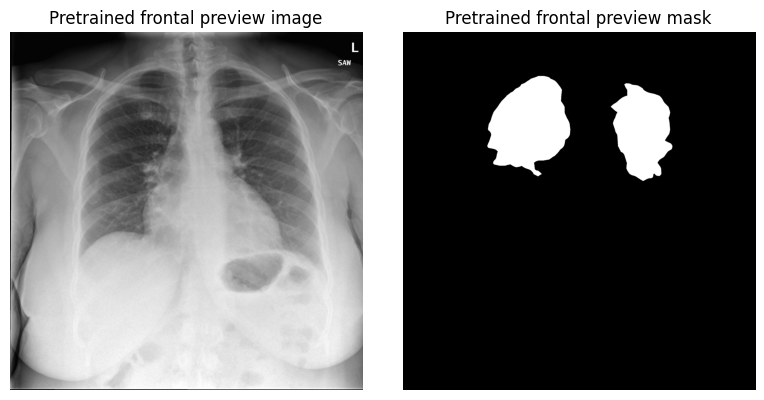

Saved segmentation preview to: PROJECT_ROOT\Experiments\outputs\experiment_04_segmentation\segmentation\preview_mask.png


In [3]:
def infer_binary_lung_mask(image_path, threshold=0.5):
    image = Image.open(image_path).convert("RGB")
    original_size = image.size
    model_inputs = segmentation_image_processor(images=image, return_tensors="pt")
    model_inputs = {key: value.to(device) for key, value in model_inputs.items()}

    with torch.no_grad():
        outputs = segmentation_model(**model_inputs)
        logits = outputs.logits

    upsampled = F.interpolate(
        logits,
        size=(original_size[1], original_size[0]),
        mode="bilinear",
        align_corners=False,
    )

    if upsampled.shape[1] == 1:
        probs = torch.sigmoid(upsampled)[0, 0].cpu().numpy()
        mask = (probs > threshold).astype(np.uint8) * 255
        return mask

    probs = torch.softmax(upsampled, dim=1)[0].cpu().numpy()
    if probs.shape[0] == 2:
        foreground = probs[1]
    else:
        foreground = probs[1:].sum(axis=0)
    mask = (foreground > threshold).astype(np.uint8) * 255
    return mask


def save_segmentation_preview(image_path, mask_array, save_path, title):
    image = np.array(Image.open(image_path).convert("RGB"))
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(image)
    axes[0].set_title(f"{title} image")
    axes[0].axis("off")
    axes[1].imshow(mask_array, cmap="gray")
    axes[1].set_title(f"{title} mask")
    axes[1].axis("off")
    plt.tight_layout()
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)


preview_frontal_path = train_df.iloc[0]["frontal_path"]
preview_frontal_mask = infer_binary_lung_mask(preview_frontal_path)
preview_mask_path = PREDICTED_MASK_DIR / "preview_frontal_mask.png"
Image.fromarray(preview_frontal_mask).save(preview_mask_path)
save_segmentation_preview(
    preview_frontal_path,
    preview_frontal_mask,
    SEGMENTATION_DIR / "preview_mask.png",
    "Pretrained frontal preview",
)
print("Saved segmentation preview to:", SEGMENTATION_DIR / "preview_mask.png")


### **Generate segmentation-derived image pipelines**


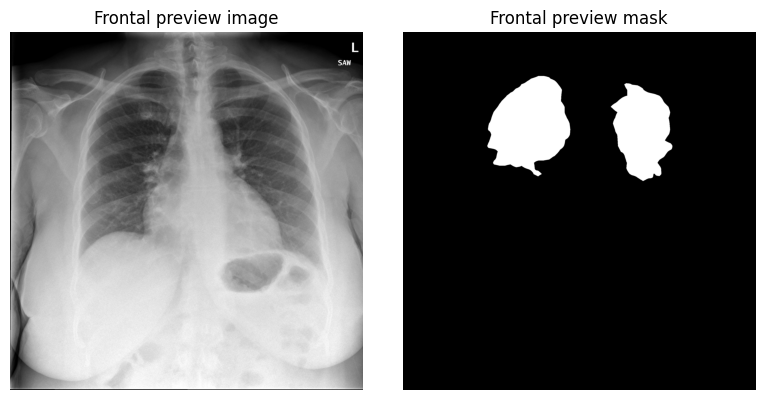

Prepare B_lung_cropped_frontal train:   0%|                                                   | 0/2200 [00:00<…

In [ ]:
def largest_bbox_from_mask(mask_array):
    ys, xs = np.where(mask_array > 0)
    if len(xs) == 0 or len(ys) == 0:
        return None
    return int(xs.min()), int(ys.min()), int(xs.max()) + 1, int(ys.max()) + 1


def save_preview(image_array, mask_array, save_path, title):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(image_array, cmap="gray")
    axes[0].set_title(f"{title} image")
    axes[0].axis("off")
    axes[1].imshow(mask_array, cmap="gray")
    axes[1].set_title(f"{title} mask")
    axes[1].axis("off")
    plt.tight_layout()
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)


mask_cache = {}


def cached_mask(path_string):
    path_key = str(Path(path_string))
    if path_key not in mask_cache:
        mask_cache[path_key] = infer_binary_lung_mask(path_key)
    return mask_cache[path_key]


def masked_rgb_array(image_path, mask_array):
    image_arr = np.array(Image.open(image_path).convert("RGB"), dtype=np.uint8)
    mask01 = (mask_array > 0).astype(np.uint8)
    return image_arr * mask01[..., None]


def cropped_frontal_array(image_path, mask_array):
    image = Image.open(image_path).convert("RGB")
    bbox = largest_bbox_from_mask(mask_array)
    if bbox is None:
        return np.array(image, dtype=np.uint8)
    cropped = image.crop(bbox)
    return np.array(cropped, dtype=np.uint8)


def ensure_parent(path):
    Path(path).parent.mkdir(parents=True, exist_ok=True)


def pipeline_image_path(split_name, pipeline_slug, view_name, original_path):
    original_name = Path(original_path).name
    return PIPELINE_IMAGE_DIR / pipeline_slug / split_name / view_name / original_name


def pipeline_mask_path(split_name, view_name, original_path):
    original_name = Path(original_path).name
    return PREDICTED_MASK_DIR / split_name / view_name / original_name


def save_rgb_array(array, save_path):
    ensure_parent(save_path)
    Image.fromarray(array.astype(np.uint8)).save(save_path)


def build_pipeline_dataframe(df, split_name, pipeline_spec):
    pipeline_df = df.copy().reset_index(drop=True)
    if pipeline_spec["mode"] == "original":
        pipeline_df["pipeline_name"] = pipeline_spec["name"]
        pipeline_df["pipeline_slug"] = pipeline_spec["slug"]
        return pipeline_df

    new_frontal_paths = []
    new_lateral_paths = []

    for _, row in tqdm(pipeline_df.iterrows(), total=len(pipeline_df), desc=f"Prepare {pipeline_spec['name']} {split_name}", dynamic_ncols=True):
        frontal_path = row["frontal_path"]
        lateral_path = row["lateral_path"]

        frontal_mask = cached_mask(frontal_path)
        frontal_mask_path = pipeline_mask_path(split_name, "frontal", frontal_path)
        ensure_parent(frontal_mask_path)
        Image.fromarray(frontal_mask).save(frontal_mask_path)
        frontal_save_path = pipeline_image_path(split_name, pipeline_spec["slug"], "frontal", frontal_path)

        if pipeline_spec["mode"] == "cropped_frontal":
            frontal_arr = cropped_frontal_array(frontal_path, frontal_mask)
            lateral_save_path = lateral_path
        elif pipeline_spec["mode"] == "masked_dual":
            lateral_mask = cached_mask(lateral_path)
            lateral_mask_path = pipeline_mask_path(split_name, "lateral", lateral_path)
            ensure_parent(lateral_mask_path)
            Image.fromarray(lateral_mask).save(lateral_mask_path)
            frontal_arr = masked_rgb_array(frontal_path, frontal_mask)
            lateral_arr = masked_rgb_array(lateral_path, lateral_mask)
            lateral_save_path = pipeline_image_path(split_name, pipeline_spec["slug"], "lateral", lateral_path)
            save_rgb_array(lateral_arr, lateral_save_path)
        else:
            raise ValueError(f"Unknown pipeline mode: {pipeline_spec['mode']}")

        save_rgb_array(frontal_arr, frontal_save_path)
        new_frontal_paths.append(str(frontal_save_path))
        new_lateral_paths.append(str(lateral_save_path))

    pipeline_df["frontal_path"] = new_frontal_paths
    pipeline_df["lateral_path"] = new_lateral_paths
    pipeline_df["pipeline_name"] = pipeline_spec["name"]
    pipeline_df["pipeline_slug"] = pipeline_spec["slug"]
    return pipeline_df


preview_frontal_path = train_df.iloc[0]["frontal_path"]
preview_frontal_mask = cached_mask(preview_frontal_path)
save_preview(
    np.array(Image.open(preview_frontal_path).convert("L")),
    preview_frontal_mask,
    SEGMENTATION_DIR / "preview_mask.png",
    "Frontal preview",
)

pipeline_datasets = {}
for pipeline_spec in PIPELINE_SPECS:
    pipeline_datasets[pipeline_spec["slug"]] = {
        "train": build_pipeline_dataframe(train_df, "train", pipeline_spec),
        "val": build_pipeline_dataframe(val_df, "val", pipeline_spec),
        "test": build_pipeline_dataframe(test_df, "test", pipeline_spec),
        "spec": pipeline_spec,
    }

print("Prepared pipeline datasets:", list(pipeline_datasets.keys()))


---

# **Part 3: Model and Training Utilities**

### **Dataset, model, training, and artifact helpers**


In [ ]:
class XRayMultimodalDataset(xray_data.XRayMultimodalDataset):
    def __init__(self, df, tokenizer, image_transform=None, max_len=MAX_LEN):
        super().__init__(df, tokenizer=tokenizer, image_transform=image_transform, max_len=max_len, label_key="labels")

DualImageEncoder = xray_models.DualImageEncoder
ResidualGatedFusionBlock = xray_models.ResidualGatedFusionBlock


class BioClinicalBertGatedFusionClassifier(xray_models.SelectedEncoderGatedFusionModel):
    def __init__(self, num_classes, freeze_bert=False, freeze_image_backbone=False, cache_dir=None):
        super().__init__(
            encoder_spec=TEXT_ENCODER_SPEC,
            num_classes=num_classes,
            fusion_block=None,
            fusion_dim=256,
            fusion_dropout=0.2,
            freeze_bert=freeze_bert,
            freeze_image_backbone=freeze_image_backbone,
            cache_dir=cache_dir,
        )

configure_optimizer = lambda model: xray_training.configure_optimizer(
    model, lr_text=LR_TEXT, lr_image=LR_IMAGE, weight_decay=WEIGHT_DECAY
)
build_scheduler = xray_training.build_scheduler


def move_optimizer_state_to_device(optimizer, device):
    for state in optimizer.state.values():
        for key, value in state.items():
            if torch.is_tensor(value):
                state[key] = value.to(device)


def compute_metrics(y_true, y_pred):
    report = classification_report(
        y_true,
        y_pred,
        target_names=label_names,
        output_dict=True,
        zero_division=0,
    )
    per_class_df = (
        pd.DataFrame(report)
        .transpose()
        .iloc[: len(label_names)]
        .reset_index()
        .rename(columns={"index": "class_name"})
    )
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
        "report": report,
        "per_class_df": per_class_df,
        "confusion_matrix": confusion_matrix(y_true, y_pred),
    }

def to_jsonable(value):
    if isinstance(value, dict):
        return {key: to_jsonable(item) for key, item in value.items()}
    if isinstance(value, list):
        return [to_jsonable(item) for item in value]
    if isinstance(value, tuple):
        return [to_jsonable(item) for item in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    return value


def save_json(payload, path):
    with open(path, "w", encoding="utf-8") as handle:
        json.dump(to_jsonable(payload), handle, indent=2)


def save_confusion_matrix_figure(cm, title, save_path):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(range(len(label_names)))
    ax.set_yticks(range(len(label_names)))
    ax.set_xticklabels(label_names, rotation=45, ha="right")
    ax.set_yticklabels(label_names)
    for i in range(len(label_names)):
        for j in range(len(label_names)):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center")
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def plot_history(history_df, title, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
    axes[0].set_title(f"{title} Loss")
    axes[0].legend()
    axes[1].plot(history_df["epoch"], history_df["train_acc"], label="train_acc")
    axes[1].plot(history_df["epoch"], history_df["val_acc"], label="val_acc")
    axes[1].set_title(f"{title} Accuracy")
    axes[1].legend()
    plt.tight_layout()
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for batch in tqdm(loader, desc="Train Fusion", leave=False, dynamic_ncols=True):
        frontal = batch["frontal"].to(device)
        lateral = batch["lateral"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = model(frontal, lateral, input_ids, attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        preds = logits.argmax(dim=1)
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (preds == labels).sum().item()
        total_count += batch_size

    return total_loss / total_count, total_correct / total_count

@torch.no_grad()
def evaluate_classifier(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    y_true = []
    y_pred = []

    for batch in tqdm(loader, desc="Eval Fusion", leave=False, dynamic_ncols=True):
        frontal = batch["frontal"].to(device)
        lateral = batch["lateral"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = model(frontal, lateral, input_ids, attention_mask)
        loss = criterion(logits, labels)
        preds = logits.argmax(dim=1)

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (preds == labels).sum().item()
        total_count += batch_size
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    return total_loss / total_count, total_correct / total_count, np.array(y_true), np.array(y_pred)

def save_split_artifacts(split_name, metrics, run_dir, title_prefix):
    save_json(
        {"accuracy": metrics["accuracy"], "macro_f1": metrics["macro_f1"]},
        run_dir / f"{split_name}_metrics.json",
    )
    save_json(metrics["report"], run_dir / f"{split_name}_classification_report.json")
    metrics["per_class_df"].to_csv(run_dir / f"{split_name}_per_class_metrics.csv", index=False)
    pd.DataFrame(
        metrics["confusion_matrix"],
        index=label_names,
        columns=label_names,
    ).to_csv(run_dir / f"{split_name}_confusion_matrix.csv")
    save_confusion_matrix_figure(
        metrics["confusion_matrix"],
        f"{title_prefix} {split_name.title()} Confusion Matrix",
        run_dir / f"{split_name}_confusion_matrix.png",
    )

def extract_per_class_rows(metrics, pipeline_name, pipeline_slug, split_name):
    df = metrics["per_class_df"].copy()
    df.insert(0, "split", split_name)
    df.insert(0, "pipeline_slug", pipeline_slug)
    df.insert(0, "pipeline_name", pipeline_name)
    return df

def run_pipeline_experiment(pipeline_bundle):
    pipeline_spec = pipeline_bundle["spec"]
    run_dir = OUTPUT_DIR / pipeline_spec["slug"]
    run_dir.mkdir(parents=True, exist_ok=True)

    train_loader = DataLoader(
        XRayMultimodalDataset(pipeline_bundle["train"], tokenizer, image_transform=image_transform),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
    )
    val_loader = DataLoader(
        XRayMultimodalDataset(pipeline_bundle["val"], tokenizer, image_transform=image_transform),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )
    test_loader = DataLoader(
        XRayMultimodalDataset(pipeline_bundle["test"], tokenizer, image_transform=image_transform),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )

    class_counts = pipeline_bundle["train"]["clean_label"].value_counts()
    class_weights = torch.tensor(
        [len(pipeline_bundle["train"]) / class_counts[label] for label in label_names],
        dtype=torch.float32,
        device=device,
    )

    model = BioClinicalBertGatedFusionClassifier(
        num_classes=num_classes,
        freeze_bert=FREEZE_BERT,
        freeze_image_backbone=FREEZE_IMAGE_BACKBONE,
        cache_dir=HF_CACHE_DIR,
    ).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = configure_optimizer(model)
    scheduler = build_scheduler(optimizer)

    history = []
    best_val_acc = -math.inf
    best_epoch = -1
    start_epoch = 1
    resumed_from_checkpoint = False
    best_checkpoint_path = run_dir / "best_checkpoint.pt"
    last_checkpoint_path = run_dir / "last_checkpoint.pt"

    if last_checkpoint_path.exists():
        resume_checkpoint = torch.load(last_checkpoint_path, map_location=device, weights_only=False)
        model.load_state_dict(resume_checkpoint["model_state_dict"])
        if "optimizer_state_dict" in resume_checkpoint:
            optimizer.load_state_dict(resume_checkpoint["optimizer_state_dict"])
            move_optimizer_state_to_device(optimizer, device)
        if "scheduler_state_dict" in resume_checkpoint:
            scheduler.load_state_dict(resume_checkpoint["scheduler_state_dict"])
        history = list(resume_checkpoint.get("history", []))
        best_val_acc = float(resume_checkpoint.get("best_val_acc", best_val_acc))
        best_epoch = int(resume_checkpoint.get("best_epoch", resume_checkpoint.get("epoch", best_epoch)))
        completed_epoch = int(resume_checkpoint.get("epoch", 0))
        start_epoch = completed_epoch + 1
        resumed_from_checkpoint = True
        print(
            f"Resuming {pipeline_spec['name']} from epoch {completed_epoch}; "
            f"next epoch is {start_epoch}/{EPOCHS}."
        )

    if start_epoch > EPOCHS:
        print(f"{pipeline_spec['name']} already has a complete checkpoint at epoch {start_epoch - 1}.")

    for epoch in range(start_epoch, EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, _, _ = evaluate_classifier(model, val_loader, criterion)
        scheduler.step()
        lr_values = [group["lr"] for group in optimizer.param_groups]

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "train_acc": train_acc,
                "val_loss": val_loss,
                "val_acc": val_acc,
                "lr_min": min(lr_values),
                "lr_max": max(lr_values),
            }
        )
        print(
            f"{pipeline_spec['name']} epoch {epoch}/{EPOCHS} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
        )

        is_best = val_acc >= best_val_acc
        if is_best:
            best_val_acc = float(val_acc)
            best_epoch = epoch

        checkpoint_payload = {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "pipeline_spec": pipeline_spec,
            "epoch": epoch,
            "best_epoch": best_epoch,
            "best_val_acc": best_val_acc,
            "current_val_loss": float(val_loss),
            "current_val_acc": float(val_acc),
            "history": history,
            "label_names": label_names,
            "img_size": IMG_SIZE,
            "batch_size": BATCH_SIZE,
            "num_workers": NUM_WORKERS,
            "epochs": EPOCHS,
            "lr_text": LR_TEXT,
            "lr_image": LR_IMAGE,
            "weight_decay": WEIGHT_DECAY,
            "max_len": MAX_LEN,
            "freeze_bert": FREEZE_BERT,
            "freeze_image_backbone": FREEZE_IMAGE_BACKBONE,
            "lr_schedule_name": LR_SCHEDULE_NAME,
            "model_architecture": "Bio_ClinicalBERT residual gated fusion",
            "text_encoder": TEXT_ENCODER_NAME,
            "encoder_spec": TEXT_ENCODER_SPEC,
            "fusion_block": "ResidualGatedFusionBlock",
            "checkpoint_policy": "last checkpoint saved every epoch; best checkpoint saved on validation accuracy improvement",
        }
        torch.save(checkpoint_payload, last_checkpoint_path)
        if is_best:
            torch.save(checkpoint_payload, best_checkpoint_path)

    history_df = pd.DataFrame(history)
    history_df.to_csv(run_dir / "training_history.csv", index=False)
    plot_history(history_df, pipeline_spec["name"], run_dir / "training_curves.png")

    evaluation_checkpoint_path = best_checkpoint_path if best_checkpoint_path.exists() else last_checkpoint_path
    if not evaluation_checkpoint_path.exists():
        raise FileNotFoundError(f"No checkpoint found for {pipeline_spec['name']}: {evaluation_checkpoint_path}")
    checkpoint = torch.load(evaluation_checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])

    val_loss, val_acc, val_y_true, val_y_pred = evaluate_classifier(model, val_loader, criterion)
    test_loss, test_acc, test_y_true, test_y_pred = evaluate_classifier(model, test_loader, criterion)

    val_metrics = compute_metrics(val_y_true, val_y_pred)
    test_metrics = compute_metrics(test_y_true, test_y_pred)

    save_split_artifacts("validation", val_metrics, run_dir, pipeline_spec["name"])
    save_split_artifacts("test", test_metrics, run_dir, pipeline_spec["name"])

    run_summary = {
        "pipeline_name": pipeline_spec["name"],
        "pipeline_slug": pipeline_spec["slug"],
        "description": pipeline_spec["description"],
        "model_architecture": "Bio_ClinicalBERT residual gated fusion",
        "text_encoder": TEXT_ENCODER_NAME,
        "fusion_block": "ResidualGatedFusionBlock",
        "best_epoch": best_epoch,
        "val_loss": float(val_loss),
        "val_accuracy": float(val_acc),
        "val_macro_f1": float(val_metrics["macro_f1"]),
        "test_loss": float(test_loss),
        "test_accuracy": float(test_acc),
        "test_macro_f1": float(test_metrics["macro_f1"]),
        "checkpoint_path": str(evaluation_checkpoint_path),
        "best_checkpoint_path": str(best_checkpoint_path),
        "last_checkpoint_path": str(last_checkpoint_path),
        "resumed_from_checkpoint": resumed_from_checkpoint,
        "checkpoint_policy": "last checkpoint saved every epoch; best checkpoint saved on validation accuracy improvement",
    }
    save_json(run_summary, run_dir / "run_summary.json")

    per_class_df = pd.concat(
        [
            extract_per_class_rows(val_metrics, pipeline_spec["name"], pipeline_spec["slug"], "validation"),
            extract_per_class_rows(test_metrics, pipeline_spec["name"], pipeline_spec["slug"], "test"),
        ],
        ignore_index=True,
    )
    per_class_df.to_csv(run_dir / "per_class_metrics_all_splits.csv", index=False)

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return run_summary, per_class_df


---

# **Part 4: Train Segmentation Pipelines**

### **Run and compare pipeline experiments**


Running pipeline: A_original_full
Original full frontal and original lateral images.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Resuming A_original_full from epoch 10; next epoch is 11/10.
A_original_full already has a complete checkpoint at epoch 10.


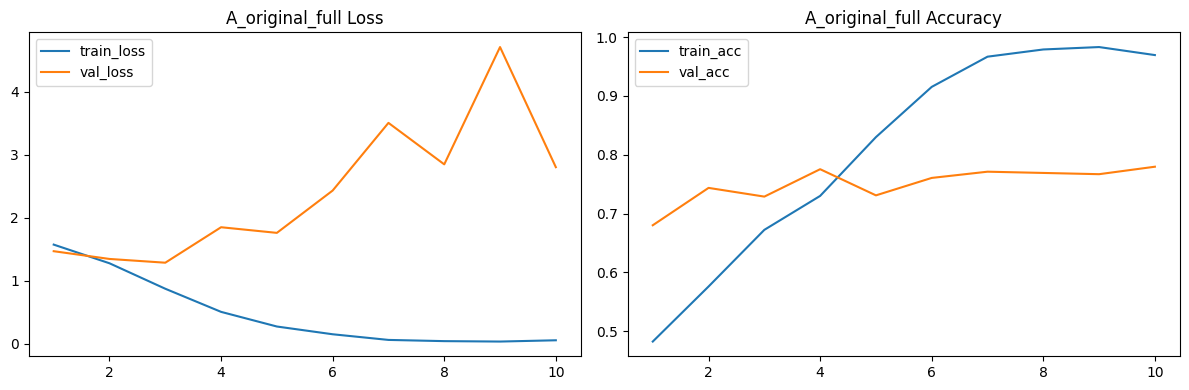

Eval Fusion:   0%|                                                                              | 0/15 [00:00<…

Eval Fusion:   0%|                                                                              | 0/15 [00:00<…

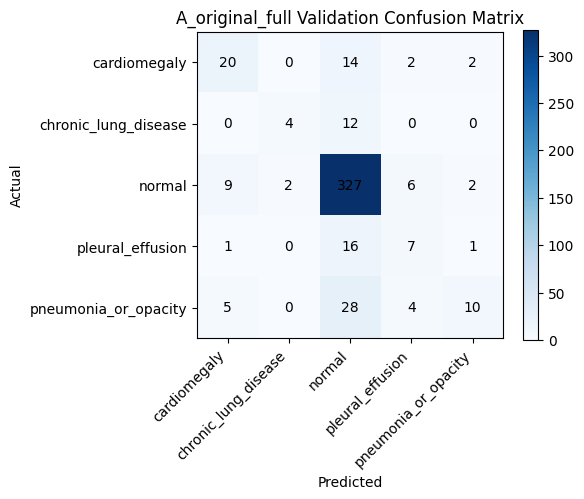

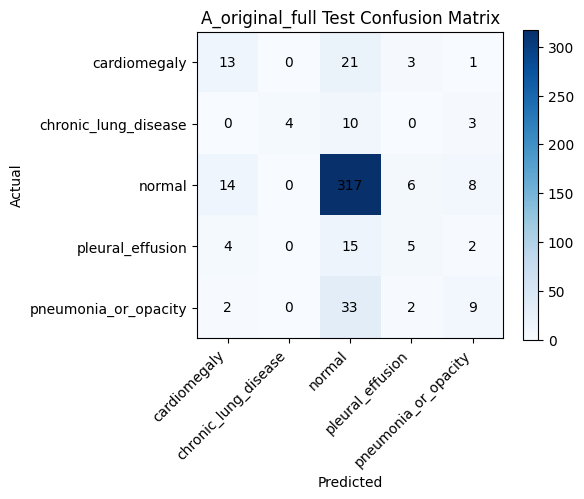

Running pipeline: B_lung_cropped_frontal
Lung-cropped frontal image with original lateral image.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Resuming B_lung_cropped_frontal from epoch 10; next epoch is 11/10.
B_lung_cropped_frontal already has a complete checkpoint at epoch 10.


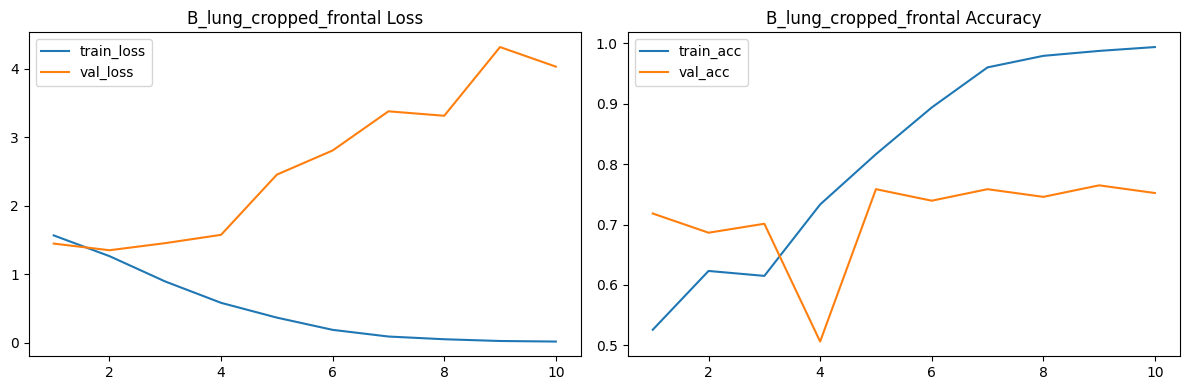

Eval Fusion:   0%|                                                                              | 0/15 [00:00<…

Eval Fusion:   0%|                                                                              | 0/15 [00:00<…

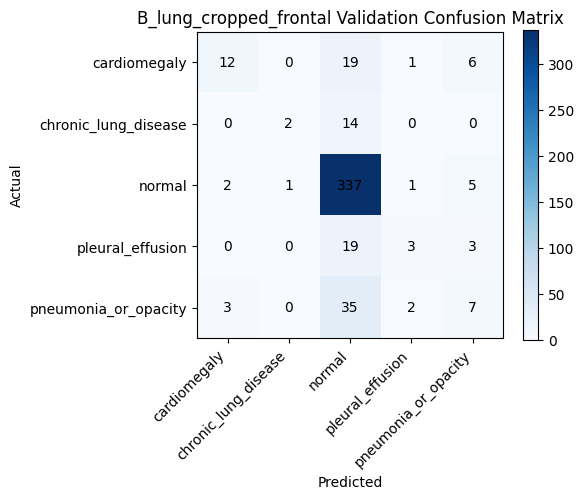

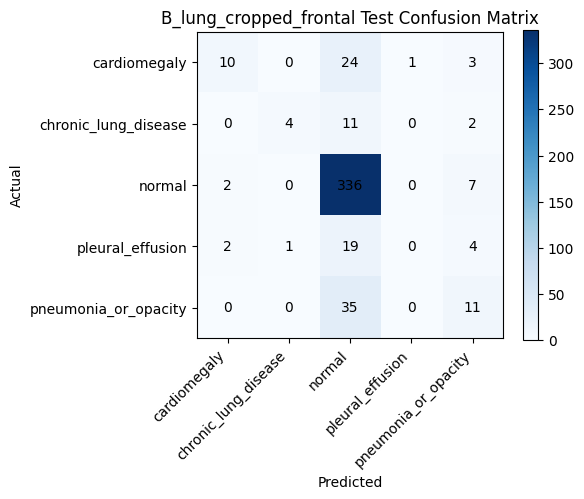

Running pipeline: C_lung_masked_dual
Predicted lung mask applied to frontal and lateral images.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Resuming C_lung_masked_dual from epoch 10; next epoch is 11/10.
C_lung_masked_dual already has a complete checkpoint at epoch 10.


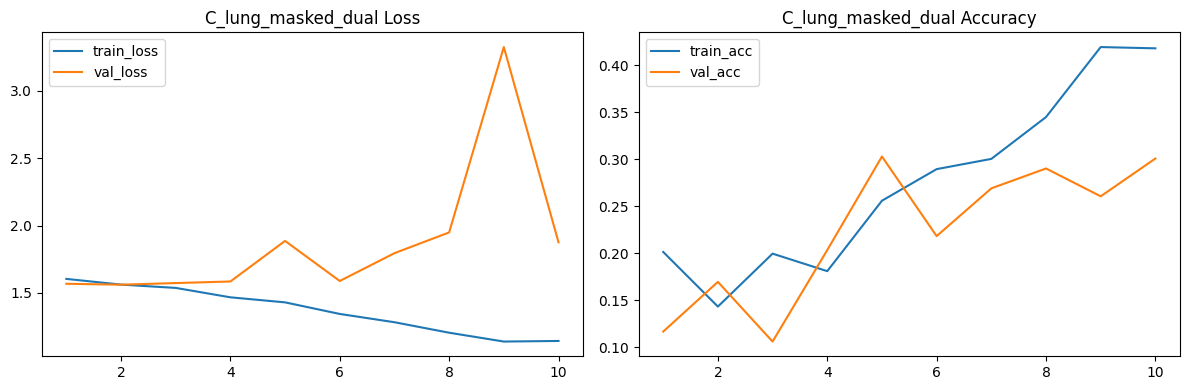

Eval Fusion:   0%|                                                                              | 0/15 [00:00<…

Eval Fusion:   0%|                                                                              | 0/15 [00:00<…

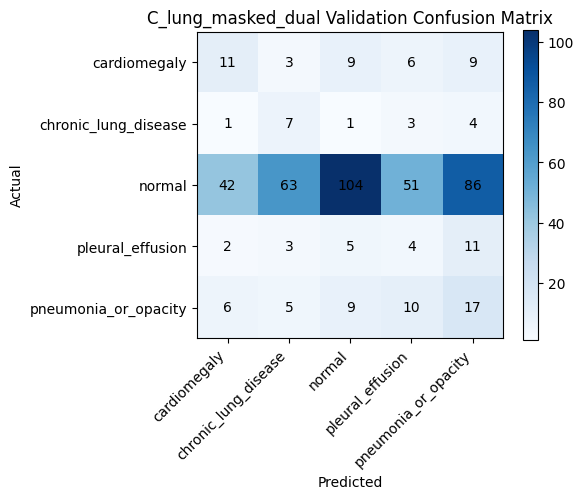

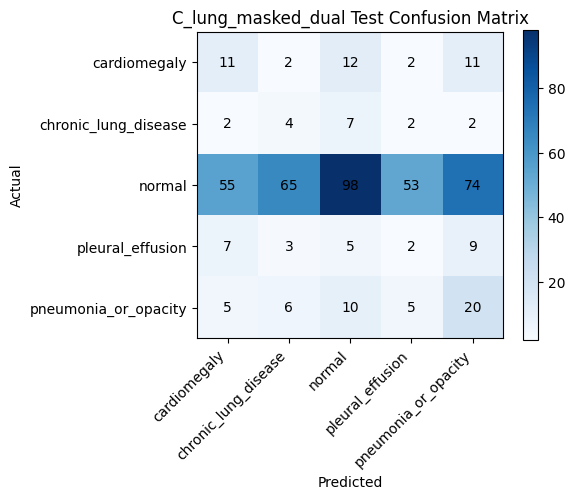

,pipeline_name,pipeline_slug,description,model_architecture,text_encoder,fusion_block,best_epoch,val_loss,val_accuracy,val_macro_f1,test_loss,test_accuracy,test_macro_f1,checkpoint_path,best_checkpoint_path,last_checkpoint_path,resumed_from_checkpoint,checkpoint_policy
0,B_lung_cropped_frontal,b_lung_cropped_frontal,Lung-cropped frontal image with original later...,Bio_ClinicalBERT residual gated fusion,emilyalsentzer/Bio_ClinicalBERT,ResidualGatedFusionBlock,9,4.319770,0.764831,0.383119,4.975465,0.764831,0.384470,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,True,last checkpoint saved every epoch; best checkp...
1,A_original_full,a_original_full,Original full frontal and original lateral ima...,Bio_ClinicalBERT residual gated fusion,emilyalsentzer/Bio_ClinicalBERT,ResidualGatedFusionBlock,10,2.804388,0.779661,0.486512,3.423183,0.737288,0.420343,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,True,last checkpoint saved every epoch; best checkp...
2,C_lung_masked_dual,c_lung_masked_dual,Predicted lung mask applied to frontal and lat...,Bio_ClinicalBERT residual gated fusion,emilyalsentzer/Bio_ClinicalBERT,ResidualGatedFusionBlock,5,1.885831,0.302966,0.215872,2.096911,0.286017,0.194235,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,True,last checkpoint saved every epoch; best checkp...


,pipeline_name,pipeline_slug,split,class_name,precision,recall,f1-score,support
0,A_original_full,a_original_full,validation,cardiomegaly,0.571429,0.526316,0.547945,38.0
1,A_original_full,a_original_full,validation,chronic_lung_disease,0.666667,0.250000,0.363636,16.0
2,A_original_full,a_original_full,validation,normal,0.823678,0.945087,0.880215,346.0
3,A_original_full,a_original_full,validation,pleural_effusion,0.368421,0.280000,0.318182,25.0
4,A_original_full,a_original_full,validation,pneumonia_or_opacity,0.666667,0.212766,0.322581,47.0
5,A_original_full,a_original_full,test,cardiomegaly,0.393939,0.342105,0.366197,38.0
6,A_original_full,a_original_full,test,chronic_lung_disease,1.000000,0.235294,0.380952,17.0
7,A_original_full,a_original_full,test,normal,0.800505,0.918841,0.855601,345.0
8,A_original_full,a_original_full,test,pleural_effusion,0.312500,0.192308,0.238095,26.0
9,A_original_full,a_original_full,test,pneumonia_or_opacity,0.391304,0.195652,0.260870,46.0


Saved pipeline summary to: PROJECT_ROOT\Experiments\outputs\experiment_04_segmentation\pipeline_summary.csv


In [8]:
pipeline_summaries = []
pipeline_per_class_tables = []

for pipeline_spec in PIPELINE_SPECS:
    print("=" * 80)
    print("Running pipeline:", pipeline_spec["name"])
    print(pipeline_spec["description"])
    print("=" * 80)
    run_summary, run_per_class_df = run_pipeline_experiment(
        pipeline_datasets[pipeline_spec["slug"]]
    )
    pipeline_summaries.append(run_summary)
    pipeline_per_class_tables.append(run_per_class_df)

pipeline_summary_df = pd.DataFrame(pipeline_summaries).sort_values(
    ["test_accuracy", "test_macro_f1"],
    ascending=[False, False],
).reset_index(drop=True)
pipeline_summary_df.to_csv(OUTPUT_DIR / "pipeline_summary.csv", index=False)

pipeline_per_class_summary_df = pd.concat(pipeline_per_class_tables, ignore_index=True)
pipeline_per_class_summary_df.to_csv(OUTPUT_DIR / "per_class_summary.csv", index=False)

display(pipeline_summary_df)
display(pipeline_per_class_summary_df.head(18))
print("Saved pipeline summary to:", OUTPUT_DIR / "pipeline_summary.csv")


---

# **Part 5: Results and Reporting**

### **Load saved pipeline results for reporting**


In [9]:
project_root = Path.cwd().resolve()
if not (project_root / "Experiments").exists():
    project_root = project_root.parent

experiment_dir = project_root / "Experiments" / "outputs" / "experiment_04_segmentation"
summary_path = experiment_dir / "pipeline_summary.csv"
per_class_path = experiment_dir / "per_class_summary.csv"

summary_df = pd.read_csv(summary_path)
per_class_df = pd.read_csv(per_class_path)

summary_df

,pipeline_name,pipeline_slug,description,model_architecture,text_encoder,fusion_block,best_epoch,val_loss,val_accuracy,val_macro_f1,test_loss,test_accuracy,test_macro_f1,checkpoint_path,best_checkpoint_path,last_checkpoint_path,resumed_from_checkpoint,checkpoint_policy
0,B_lung_cropped_frontal,b_lung_cropped_frontal,Lung-cropped frontal image with original later...,Bio_ClinicalBERT residual gated fusion,emilyalsentzer/Bio_ClinicalBERT,ResidualGatedFusionBlock,9,4.319770,0.764831,0.383119,4.975465,0.764831,0.384470,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,True,last checkpoint saved every epoch; best checkp...
1,A_original_full,a_original_full,Original full frontal and original lateral ima...,Bio_ClinicalBERT residual gated fusion,emilyalsentzer/Bio_ClinicalBERT,ResidualGatedFusionBlock,10,2.804388,0.779661,0.486512,3.423183,0.737288,0.420343,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,True,last checkpoint saved every epoch; best checkp...
2,C_lung_masked_dual,c_lung_masked_dual,Predicted lung mask applied to frontal and lat...,Bio_ClinicalBERT residual gated fusion,emilyalsentzer/Bio_ClinicalBERT,ResidualGatedFusionBlock,5,1.885831,0.302966,0.215872,2.096911,0.286017,0.194235,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,PROJECT_ROOT\Exp...,True,last checkpoint saved every epoch; best checkp...


### **Build pipeline-level delta table**


In [10]:
baseline_row = summary_df.loc[summary_df["pipeline_slug"] == "a_original_full"].iloc[0]

report_table = summary_df.copy()
report_table["delta_test_accuracy_vs_A"] = report_table["test_accuracy"] - baseline_row["test_accuracy"]
report_table["delta_test_macro_f1_vs_A"] = report_table["test_macro_f1"] - baseline_row["test_macro_f1"]
report_table["accuracy_rank"] = report_table["test_accuracy"].rank(ascending=False, method="min").astype(int)
report_table["macro_f1_rank"] = report_table["test_macro_f1"].rank(ascending=False, method="min").astype(int)

display_cols = [
    "pipeline_name",
    "test_accuracy",
    "test_macro_f1",
    "delta_test_accuracy_vs_A",
    "delta_test_macro_f1_vs_A",
    "accuracy_rank",
    "macro_f1_rank",
]

display(report_table[display_cols].sort_values("accuracy_rank"))


,pipeline_name,test_accuracy,test_macro_f1,delta_test_accuracy_vs_A,delta_test_macro_f1_vs_A,accuracy_rank,macro_f1_rank
0,B_lung_cropped_frontal,0.764831,0.384470,0.027542,-0.035873,1,2
1,A_original_full,0.737288,0.420343,0.000000,0.000000,2,1
2,C_lung_masked_dual,0.286017,0.194235,-0.451271,-0.226108,3,3


### **Compare per-class performance against original images**


In [11]:
test_per_class = per_class_df[per_class_df["split"] == "test"].copy()
baseline_per_class = (
    test_per_class[test_per_class["pipeline_slug"] == "a_original_full"]
    .set_index("class_name")[["precision", "recall", "f1-score", "support"]]
    .rename(
        columns={
            "precision": "baseline_precision",
            "recall": "baseline_recall",
            "f1-score": "baseline_f1",
            "support": "support",
        }
    )
)

comparison_frames = []
for slug in ["b_lung_cropped_frontal", "c_lung_masked_dual"]:
    current = (
        test_per_class[test_per_class["pipeline_slug"] == slug]
        .set_index("class_name")[["precision", "recall", "f1-score"]]
        .rename(
            columns={
                "precision": f"{slug}_precision",
                "recall": f"{slug}_recall",
                "f1-score": f"{slug}_f1",
            }
        )
    )
    comparison_frames.append(current)

per_class_compare = baseline_per_class.join(comparison_frames, how="left")
per_class_compare["b_delta_f1_vs_A"] = per_class_compare["b_lung_cropped_frontal_f1"] - per_class_compare["baseline_f1"]
per_class_compare["c_delta_f1_vs_A"] = per_class_compare["c_lung_masked_dual_f1"] - per_class_compare["baseline_f1"]

display(
    per_class_compare.sort_values("b_delta_f1_vs_A", ascending=False)
)


,baseline_precision,baseline_recall,baseline_f1,support,b_lung_cropped_frontal_precision,b_lung_cropped_frontal_recall,b_lung_cropped_frontal_f1,c_lung_masked_dual_precision,c_lung_masked_dual_recall,c_lung_masked_dual_f1,b_delta_f1_vs_A,c_delta_f1_vs_A
class_name,,,,,,,,,,,,
pneumonia_or_opacity,0.391304,0.195652,0.260870,46.0,0.407407,0.239130,0.301370,0.172414,0.434783,0.246914,0.040500,-0.013956
cardiomegaly,0.393939,0.342105,0.366197,38.0,0.714286,0.263158,0.384615,0.137500,0.289474,0.186441,0.018418,-0.179757
normal,0.800505,0.918841,0.855601,345.0,0.790588,0.973913,0.872727,0.742424,0.284058,0.410901,0.017127,-0.444699
chronic_lung_disease,1.000000,0.235294,0.380952,17.0,0.800000,0.235294,0.363636,0.050000,0.235294,0.082474,-0.017316,-0.298478
pleural_effusion,0.312500,0.192308,0.238095,26.0,0.000000,0.000000,0.000000,0.031250,0.076923,0.044444,-0.238095,-0.193651


### **Plot test confusion matrices**


USER_HOME\AppData\Local\Temp\ipykernel_24108\2952065216.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


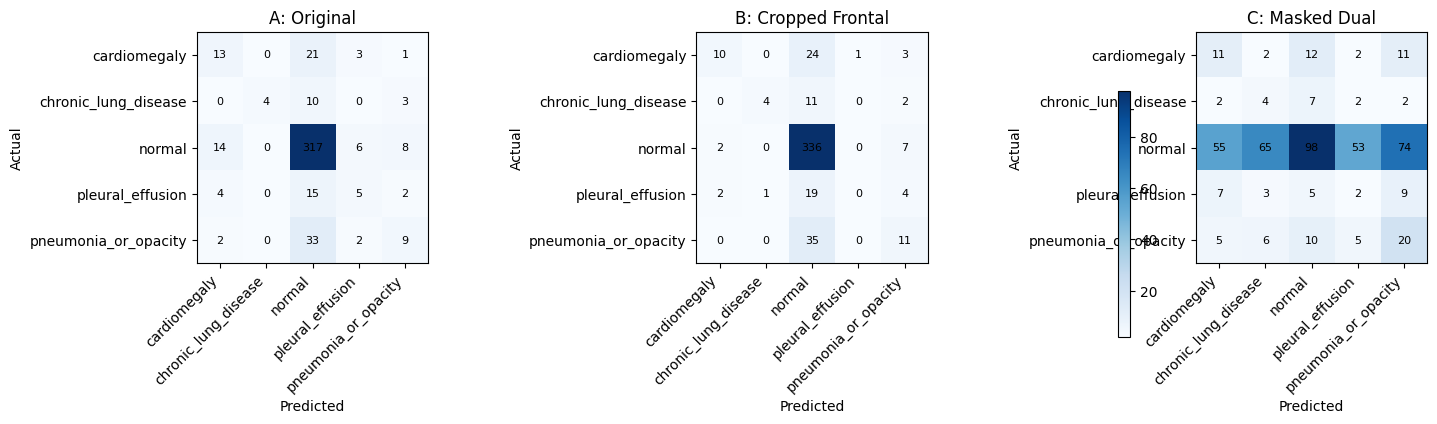

In [12]:
if "experiment_dir" not in globals():
    project_root = Path.cwd().resolve()
    if not (project_root / "Experiments").exists():
        project_root = project_root.parent
    experiment_dir = project_root / "Experiments" / "outputs" / "experiment_04_segmentation"

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, slug, title in zip(
    axes,
    ["a_original_full", "b_lung_cropped_frontal", "c_lung_masked_dual"],
    ["A: Original", "B: Cropped Frontal", "C: Masked Dual"],
):
    cm_path = experiment_dir / slug / "test_confusion_matrix.csv"
    cm_df = pd.read_csv(cm_path, index_col=0)
    im = ax.imshow(cm_df.values, cmap="Blues")
    ax.set_title(title)
    ax.set_xticks(range(len(cm_df.columns)))
    ax.set_xticklabels(cm_df.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(cm_df.index)))
    ax.set_yticklabels(cm_df.index)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    for i in range(cm_df.shape[0]):
        for j in range(cm_df.shape[1]):
            ax.text(j, i, int(cm_df.iloc[i, j]), ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.tight_layout()
plt.show()


### **Visualize segmentation pipeline examples**


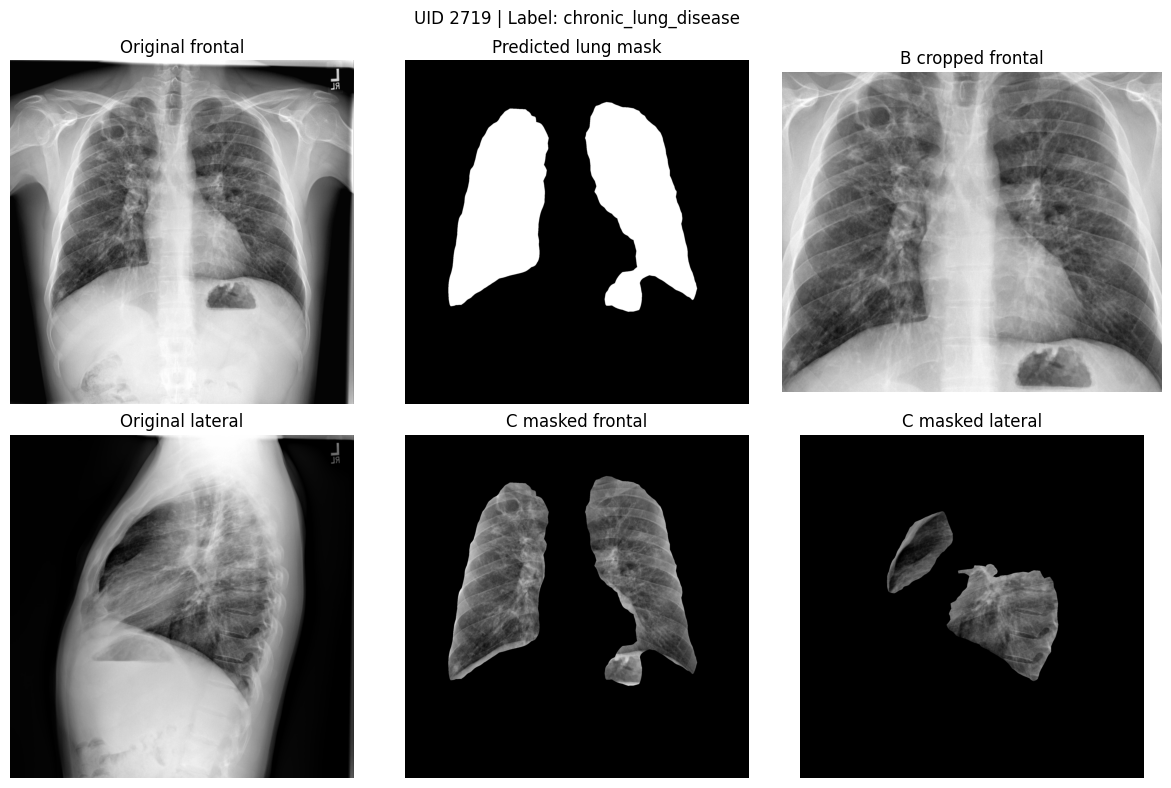

In [13]:
if "experiment_dir" not in globals():
    project_root = Path.cwd().resolve()
    if not (project_root / "Experiments").exists():
        project_root = project_root.parent
    experiment_dir = project_root / "Experiments" / "outputs" / "experiment_04_segmentation"

test_df = pd.read_csv(project_root / "splits" / "test.csv")

def show_pipeline_example(sample_idx=0):
    row = test_df.iloc[sample_idx]
    filename = Path(row["frontal_path"]).name
    lateral_name = Path(row["lateral_path"]).name

    original_frontal = Image.open(row["frontal_path"]).convert("RGB")
    original_lateral = Image.open(row["lateral_path"]).convert("RGB")
    cropped_frontal = Image.open(
        experiment_dir / "derived_images" / "b_lung_cropped_frontal" / "test" / "frontal" / filename
    ).convert("RGB")
    masked_frontal = Image.open(
        experiment_dir / "derived_images" / "c_lung_masked_dual" / "test" / "frontal" / filename
    ).convert("RGB")
    masked_lateral = Image.open(
        experiment_dir / "derived_images" / "c_lung_masked_dual" / "test" / "lateral" / lateral_name
    ).convert("RGB")
    frontal_mask = Image.open(
        experiment_dir / "predicted_masks" / "test" / "frontal" / filename
    ).convert("L")

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    panels = [
        (original_frontal, "Original frontal"),
        (frontal_mask, "Predicted lung mask"),
        (cropped_frontal, "B cropped frontal"),
        (original_lateral, "Original lateral"),
        (masked_frontal, "C masked frontal"),
        (masked_lateral, "C masked lateral"),
    ]

    for ax, (img, title) in zip(axes.ravel(), panels):
        ax.imshow(img, cmap="gray" if img.mode == "L" else None)
        ax.set_title(title)
        ax.axis("off")

    plt.suptitle(f"UID {row['uid']} | Label: {row['clean_label']}")
    plt.tight_layout()
    plt.show()


show_pipeline_example(0)



### **Print report-ready summary lines**


In [14]:
best_acc_row = summary_df.sort_values("test_accuracy", ascending=False).iloc[0]
best_f1_row = summary_df.sort_values("test_macro_f1", ascending=False).iloc[0]
baseline_row = summary_df.loc[summary_df["pipeline_slug"] == "a_original_full"].iloc[0]

report_lines = [
    f"Best test accuracy: {best_acc_row['pipeline_name']} ({best_acc_row['test_accuracy']:.3f}).",
    f"Best test macro F1: {best_f1_row['pipeline_name']} ({best_f1_row['test_macro_f1']:.3f}).",
    f"Compared with A_original_full, B changes test accuracy by {report_table.loc[report_table['pipeline_slug']=='b_lung_cropped_frontal', 'delta_test_accuracy_vs_A'].iloc[0]:+.3f} "
    f"and macro F1 by {report_table.loc[report_table['pipeline_slug']=='b_lung_cropped_frontal', 'delta_test_macro_f1_vs_A'].iloc[0]:+.3f}.",
    f"Compared with A_original_full, C changes test accuracy by {report_table.loc[report_table['pipeline_slug']=='c_lung_masked_dual', 'delta_test_accuracy_vs_A'].iloc[0]:+.3f} "
    f"and macro F1 by {report_table.loc[report_table['pipeline_slug']=='c_lung_masked_dual', 'delta_test_macro_f1_vs_A'].iloc[0]:+.3f}.",
]

for line in report_lines:
    print("-", line)


- Best test accuracy: B_lung_cropped_frontal (0.765).
- Best test macro F1: A_original_full (0.420).
- Compared with A_original_full, B changes test accuracy by +0.028 and macro F1 by -0.036.
- Compared with A_original_full, C changes test accuracy by -0.451 and macro F1 by -0.226.


### **Pipeline Result Interpretation**

The segmentation ablation shows why the project cannot choose a pipeline by accuracy alone. Lung cropping improves raw test accuracy, but the original full-image pipeline has the stronger macro F1 and avoids the pleural-effusion collapse seen in the cropped-frontal result. That makes the full-image checkpoint the better final-stage default unless a later run improves minority-class performance on the held-out test set.

### **Identify classes most helped or hurt by cropping**


In [15]:
top_b_gain = per_class_compare["b_delta_f1_vs_A"].sort_values(ascending=False)
top_b_drop = per_class_compare["b_delta_f1_vs_A"].sort_values()

print("Top classes helped by B vs A:")
display(top_b_gain.head(5))

print("Top classes hurt by B vs A:")
display(top_b_drop.head(5))


Top classes helped by B vs A:


class_name
pneumonia_or_opacity    0.040500
cardiomegaly            0.018418
normal                  0.017127
chronic_lung_disease   -0.017316
pleural_effusion       -0.238095
Name: b_delta_f1_vs_A, dtype: float64

Top classes hurt by B vs A:


class_name
pleural_effusion       -0.238095
chronic_lung_disease   -0.017316
normal                  0.017127
cardiomegaly            0.018418
pneumonia_or_opacity    0.040500
Name: b_delta_f1_vs_A, dtype: float64

---

# **Part 6: Conclusion**

This notebook shows that segmentation-derived preprocessing does not meaningfully improve results for the Bio_ClinicalBERT residual gated fusion model. The lung-cropped frontal pipeline has the highest held-out test accuracy at 0.765, which is an improvement over the original full-image pipeline's 0.737 by about 0.028. However, that accuracy gain does not carry into balanced class performance since cropped frontal macro F1 is 0.384, making it below the original full-image macro F1 of 0.420.

The original full-image pipeline remains the better default because it has the strongest validation performance and the best held-out test macro F1. Its validation accuracy/macro F1 are 0.780/0.487, and its test accuracy/macro F1 are 0.737/0.420. The cropped-frontal variant improves some classes, especially pneumonia_or_opacity and normal, but it collapses pleural_effusion test F1 to 0.000, which makes it risky for a five-class diagnostic classifier.

The masked-dual pipeline should not be carried forward. Applying predicted masks to both views drops test accuracy to 0.286 and macro F1 to 0.194, suggesting that the masking step removes or distorts useful diagnostic context rather than isolating signal. Therefore, the segmentation experiment is overall useful as an ablation but not as the default preprocessing choice.

---
